# FinCast — Dataset Analysis
Produces charts, tables, and CSVs for human review and LLM/agent consumption.

In [1]:
import os, json, yaml, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

DATA_DIR     = 'data/raw'
CONFIG_PATH  = 'gdelt_config.yaml'
ANALYSIS_DIR = 'analysis'
os.makedirs(ANALYSIS_DIR, exist_ok=True)

def save_csv(df, name):
    path = os.path.join(ANALYSIS_DIR, name)
    df.to_csv(path)
    print(f'  Saved: {path}')

print('Libraries loaded')

Libraries loaded


In [2]:
with open(CONFIG_PATH, 'r') as fh:
    cfg = yaml.safe_load(fh)
t = cfg.get('tickers', {})
ALL_TICKERS = {}
ALL_TICKERS.update({k: v for k, v in (t.get('company_queries', {}) or {}).items() if v})
ALL_TICKERS.update({k: v for k, v in (t.get('plain_names',    {}) or {}).items() if v})
ALL_TICKERS.update({k: v for k, v in (t.get('sector_queries', {}) or {}).items() if v})
BENCHMARKS      = t.get('benchmarks', {})
COMPANY_QUERIES = set((t.get('company_queries', {}) or {}).keys()) | \
                  set((t.get('plain_names',    {}) or {}).keys())
ETF_LABELS = {
    'SOXX':'Semiconductor','SKYY':'Cloud','DRIV':'EV','XLV':'Healthcare',
    'XLF':'Finance','BOTZ':'AI/Robotics','USO':'Oil','TLT':'Bonds',
    'UUP':'Dollar','XLK':'Tech ETF','CIBR':'Cybersec','SPY':'S&P500','QQQ':'Nasdaq'
}
print(f'Loaded {len(ALL_TICKERS)} ticker mappings')

Loaded 36 ticker mappings


In [15]:
def load_articles(data_dir):
    rows = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            if not f.endswith('.json'): continue
            with open(os.path.join(root, f), 'r', encoding='utf-8') as fh:
                meta = json.load(fh)
            gdelt_query = meta.get('gdelt_query', '')
            ticker      = ALL_TICKERS.get(gdelt_query)
            if not ticker: continue
            pc           = meta.get('price_changes', {})
            ticker_pc    = pc.get(gdelt_query, {})
            benchmark    = BENCHMARKS.get(ticker, 'SPY')
            benchmark_pc = pc.get(benchmark, {})
            date_str     = (meta.get('publish_date') or meta.get('scrape_date',''))[:10]
            rows.append({
                'date':            pd.to_datetime(date_str, errors='coerce'),
                'site':            meta.get('site',''),
                'gdelt_query':     gdelt_query,
                'ticker':          ticker,
                'benchmark':       benchmark,
                'category':        'company' if gdelt_query in COMPANY_QUERIES else 'sector/macro',
                'title':           meta.get('title',''),
                'summary':         meta.get('summary',''),
                'sentiment':       meta.get('sentiment'),
                'word_count':      meta.get('word_count', 0),
                'relevance':       meta.get('relevance', 1),
                'direction':       meta.get('direction', ''),
                'base_price':      ticker_pc.get('base_price'),
                'next_price':      ticker_pc.get('next_price'),
                'change_1d':       ticker_pc.get('change_1d'),
                'bucket_1d':       ticker_pc.get('bucket_1d'),
                'magnitude':       ticker_pc.get('magnitude'),
                'bm_change_1d':    benchmark_pc.get('change_1d'),
                'bm_bucket_1d':    benchmark_pc.get('bucket_1d'),
                'url':             meta.get('url',''),
            })
    return pd.DataFrame(rows)

df = load_articles(DATA_DIR).sort_values('date').reset_index(drop=True)
# Filter out low-relevance articles to focus on more impactful news
df = df[df['relevance'] > 1]
print(f'Loaded {len(df):,} articles')
print(f'Date range:      {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Unique tickers:  {df["ticker"].nunique()}')
print(f'With price data: {df["bucket_1d"].notna().sum():,}')

Loaded 968 articles
Date range:      2026-03-14 to 2026-03-31
Unique tickers:  19
With price data: 847


## 1 — Article & Ticker Distribution

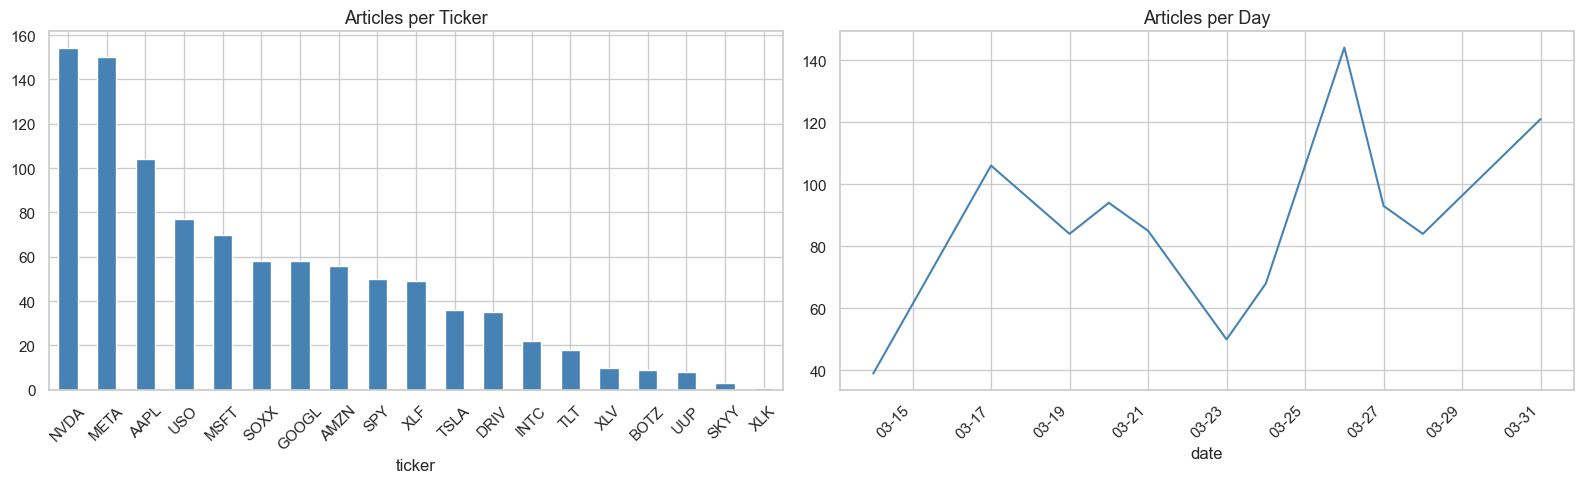

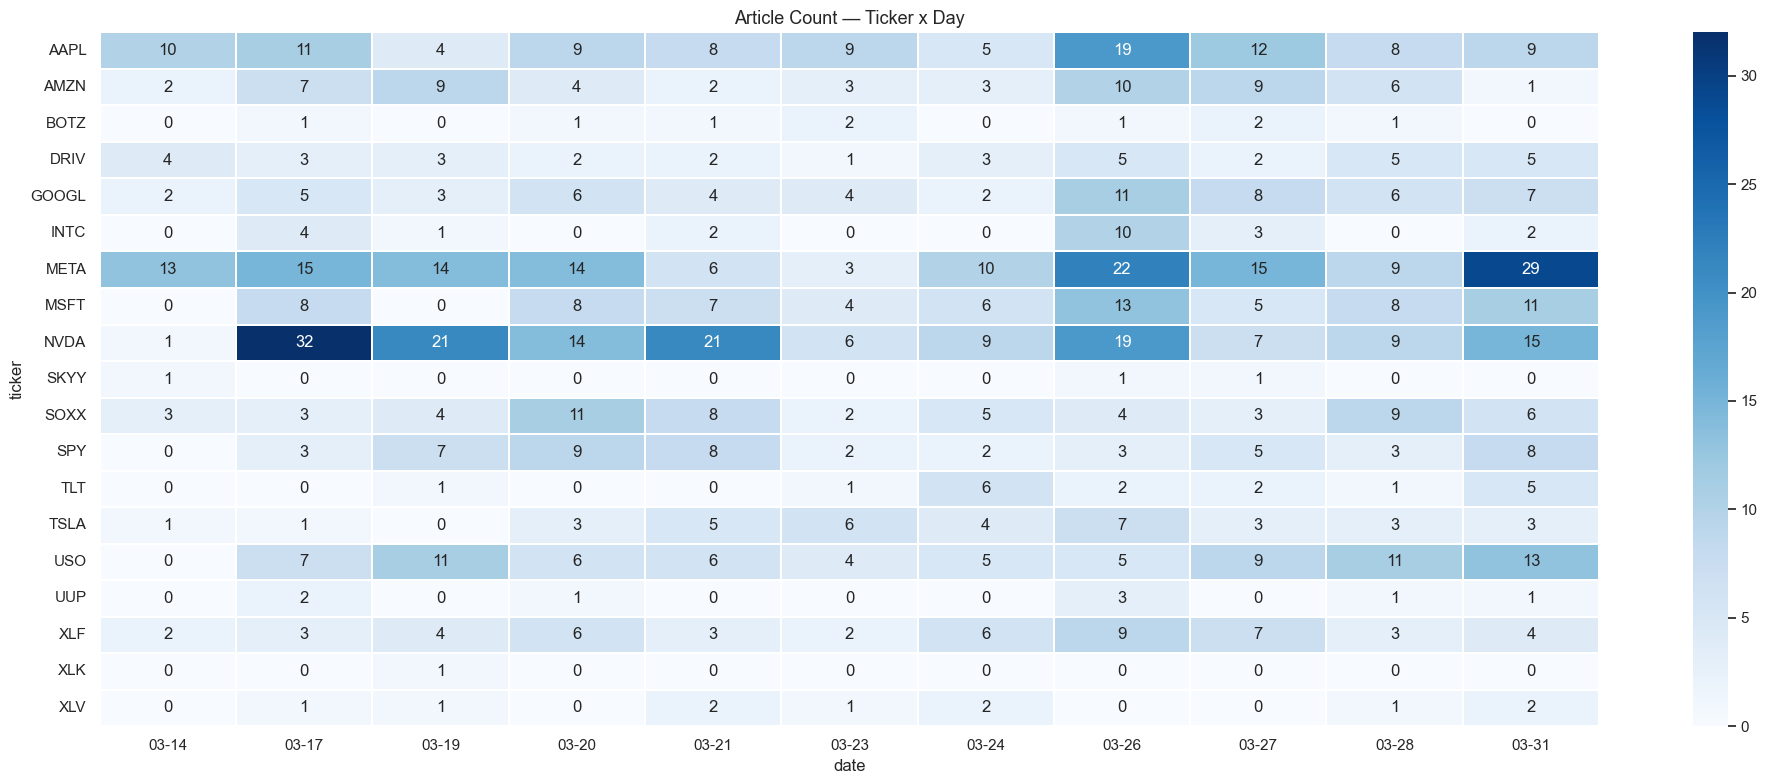


--- Articles per Ticker ---


,count,pct
ticker,,
NVDA,154,15.9
META,150,15.5
AAPL,104,10.7
USO,77,8.0
MSFT,70,7.2
SOXX,58,6.0
GOOGL,58,6.0
AMZN,56,5.8
SPY,50,5.2


  Saved: analysis\dist_articles_per_ticker.csv

--- Articles per Day ---


,count
date,
2026-03-14,39
2026-03-17,106
2026-03-19,84
2026-03-20,94
2026-03-21,85
2026-03-23,50
2026-03-24,68
2026-03-26,144
2026-03-27,93


  Saved: analysis\dist_articles_per_day.csv
  Saved: analysis\dist_ticker_day_heatmap.csv


In [16]:
# Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ticker_counts = df['ticker'].value_counts()
ticker_counts.plot(kind='bar', ax=axes[0], color='steelblue',)
axes[0].set_title('Articles per Ticker')
axes[0].tick_params(axis='x', rotation=45)
daily = df.groupby('date').size()
daily.plot(ax=axes[1], color='steelblue', linewidth=1.5)
axes[1].set_title('Articles per Day')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout(); plt.show()

pivot = df.pivot_table(index='ticker', columns=df['date'].dt.strftime('%m-%d'),
                       values='url', aggfunc='count', fill_value=0)
plt.figure(figsize=(20, 8))
sns.heatmap(pivot, cmap='Blues', linewidths=0.3, annot=True, fmt='d')
plt.title('Article Count — Ticker x Day')
plt.tight_layout(); plt.show()

# Tables
ticker_table = ticker_counts.rename('count').to_frame()
ticker_table['pct'] = (ticker_table['count'] / len(df) * 100).round(1)
print('\n--- Articles per Ticker ---')
display(ticker_table)
save_csv(ticker_table, 'dist_articles_per_ticker.csv')

daily_table = daily.rename('count').to_frame()
daily_table.index = daily_table.index.strftime('%Y-%m-%d')
print('\n--- Articles per Day ---')
display(daily_table)
save_csv(daily_table, 'dist_articles_per_day.csv')
save_csv(pivot, 'dist_ticker_day_heatmap.csv')

## 2 — Sentiment Distribution

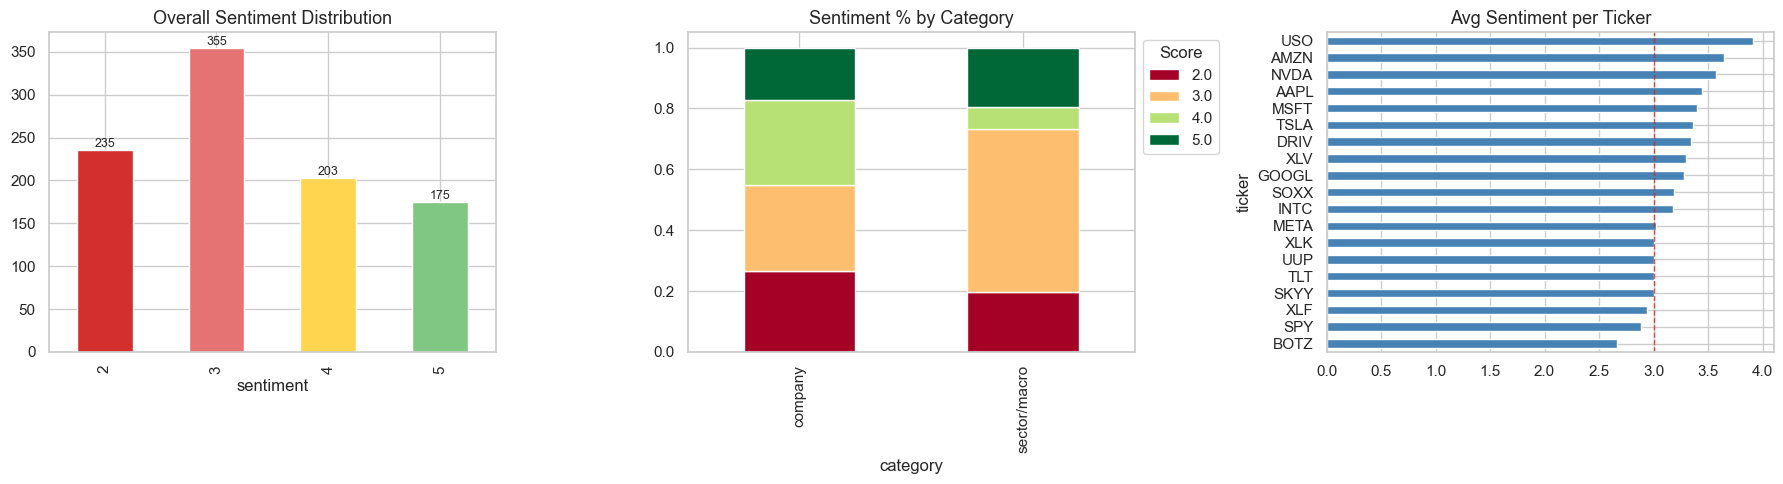

IndexError: index 3 is out of bounds for axis 0 with size 3

In [ ]:
colors = ['#d32f2f','#e57373','#ffd54f','#81c784','#2e7d32']
sent   = df['sentiment'].dropna().astype(int).value_counts().sort_index()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
sent.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Overall Sentiment Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
df.dropna(subset=['sentiment']).groupby('category')['sentiment'] \
  .value_counts(normalize=True).unstack() \
  .plot(kind='bar', ax=axes[1], colormap='RdYlGn', stacked=True)

axes[1].set_title('Sentiment % by Category')
axes[1].legend(title='Score', bbox_to_anchor=(1,1))
df.groupby('ticker')['sentiment'].mean().sort_values() \
  .plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].axvline(3, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('Avg Sentiment per Ticker')
plt.tight_layout(); plt.show()

# Sentiment × Direction heatmap
axes[3].set_title('Sentiment × Direction Distribution')
sent_dir = (
    df.dropna(subset=['sentiment', 'direction'])
      .groupby(['sentiment', 'direction'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(7, 5))
sns.heatmap(sent_dir, annot=True, fmt='d', cmap='RdYlGn', linewidths=0.3)
plt.title('Sentiment × Direction — Count Heatmap')
plt.xlabel('Direction')
plt.ylabel('Sentiment Score')
plt.tight_layout()
plt.show()

# Tables
sent_table = pd.DataFrame({'count': sent, 'pct': (sent/sent.sum()*100).round(1)})
sent_table.index.name = 'sentiment_score'
print('\n--- Sentiment Distribution ---')
display(sent_table)
save_csv(sent_table, 'dist_sentiment.csv')

sent_ticker = df.dropna(subset=['sentiment']).groupby('ticker')['sentiment'].agg(
    count='count', mean='mean', std='std', min='min', max='max').round(2)
print('\n--- Sentiment Stats per Ticker ---')
display(sent_ticker)
save_csv(sent_ticker, 'dist_sentiment_per_ticker.csv')

flat_pct = sent.get(3,0)/sent.sum()*100
if flat_pct > 50:
    print(f'\n⚠ Neutral sentiment (3) = {flat_pct:.1f}% — consider more targeted queries')

## 3 — Price Bucket Distribution

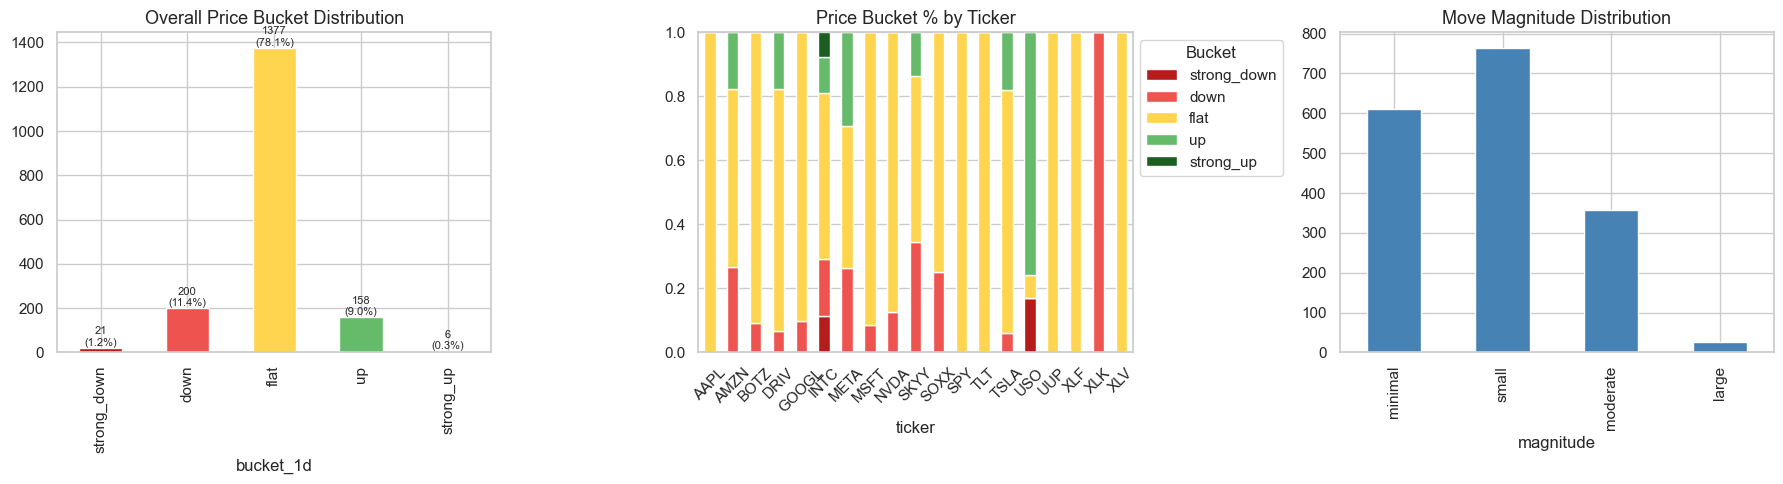


--- Price Bucket Distribution ---


,count,pct
bucket_1d,,
strong_down,21,1.2
down,200,11.4
flat,1377,78.1
up,158,9.0
strong_up,6,0.3


  Saved: analysis\dist_price_buckets.csv

--- Price Bucket % per Ticker ---


,strong_down_pct,down_pct,flat_pct,up_pct,strong_up_pct,flat_flag
ticker,,,,,,
AAPL,NaN,NaN,100.0,NaN,NaN,HIGH
AMZN,NaN,26.7,55.4,17.8,NaN,OK
BOTZ,NaN,9.3,90.7,NaN,NaN,HIGH
DRIV,NaN,6.7,75.6,17.8,NaN,HIGH
GOOGL,NaN,9.9,90.1,NaN,NaN,HIGH
INTC,11.4,17.7,51.9,11.4,7.6,OK
META,NaN,26.2,44.4,29.4,NaN,OK
MSFT,NaN,8.7,91.3,NaN,NaN,HIGH
NVDA,NaN,12.5,87.5,NaN,NaN,HIGH


  Saved: analysis\dist_price_buckets_per_ticker.csv

--- Magnitude Distribution ---


,count,pct
magnitude,,
minimal,612,34.7
small,765,43.4
moderate,358,20.3
large,27,1.5


  Saved: analysis\dist_magnitude.csv


In [6]:
labeled       = df.dropna(subset=['bucket_1d'])
bucket_order  = ['strong_down','down','flat','up','strong_up']
colors_bucket = ['#b71c1c','#ef5350','#ffd54f','#66bb6a','#1b5e20']
bucket_counts = labeled['bucket_1d'].value_counts().reindex(bucket_order, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bucket_counts.plot(kind='bar', ax=axes[0], color=colors_bucket)
axes[0].set_title('Overall Price Bucket Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(labeled)*100:.1f}%)',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)
labeled.groupby('ticker')['bucket_1d'].value_counts(normalize=True).unstack() \
    .reindex(columns=bucket_order, fill_value=0) \
    .plot(kind='bar', stacked=True, ax=axes[1], color=colors_bucket)
axes[1].set_title('Price Bucket % by Ticker')
axes[1].legend(title='Bucket', bbox_to_anchor=(1,1))
axes[1].tick_params(axis='x', rotation=45)
mag_order = ['minimal','small','moderate','large']
labeled['magnitude'].value_counts().reindex(mag_order, fill_value=0) \
    .plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Move Magnitude Distribution')
plt.tight_layout(); plt.show()

# Tables
bucket_table = pd.DataFrame({
    'count': bucket_counts,
    'pct':   (bucket_counts/bucket_counts.sum()*100).round(1)
})
print('\n--- Price Bucket Distribution ---')
display(bucket_table)
save_csv(bucket_table, 'dist_price_buckets.csv')

bucket_ticker = labeled.groupby('ticker')['bucket_1d'] \
    .value_counts(normalize=True).unstack() \
    .reindex(columns=bucket_order, fill_value=0).mul(100).round(1)
bucket_ticker.columns = [f'{c}_pct' for c in bucket_ticker.columns]
bucket_ticker['flat_flag'] = bucket_ticker.get('flat_pct', pd.Series(dtype=float)).apply(
    lambda x: 'HIGH' if x > 70 else 'OK')
print('\n--- Price Bucket % per Ticker ---')
display(bucket_ticker)
save_csv(bucket_ticker, 'dist_price_buckets_per_ticker.csv')

mag_table = labeled['magnitude'].value_counts().reindex(mag_order, fill_value=0)
mag_df = pd.DataFrame({'count': mag_table, 'pct': (mag_table/mag_table.sum()*100).round(1)})
print('\n--- Magnitude Distribution ---')
display(mag_df)
save_csv(mag_df, 'dist_magnitude.csv')

## 4 — Sentiment vs Price Mismatch

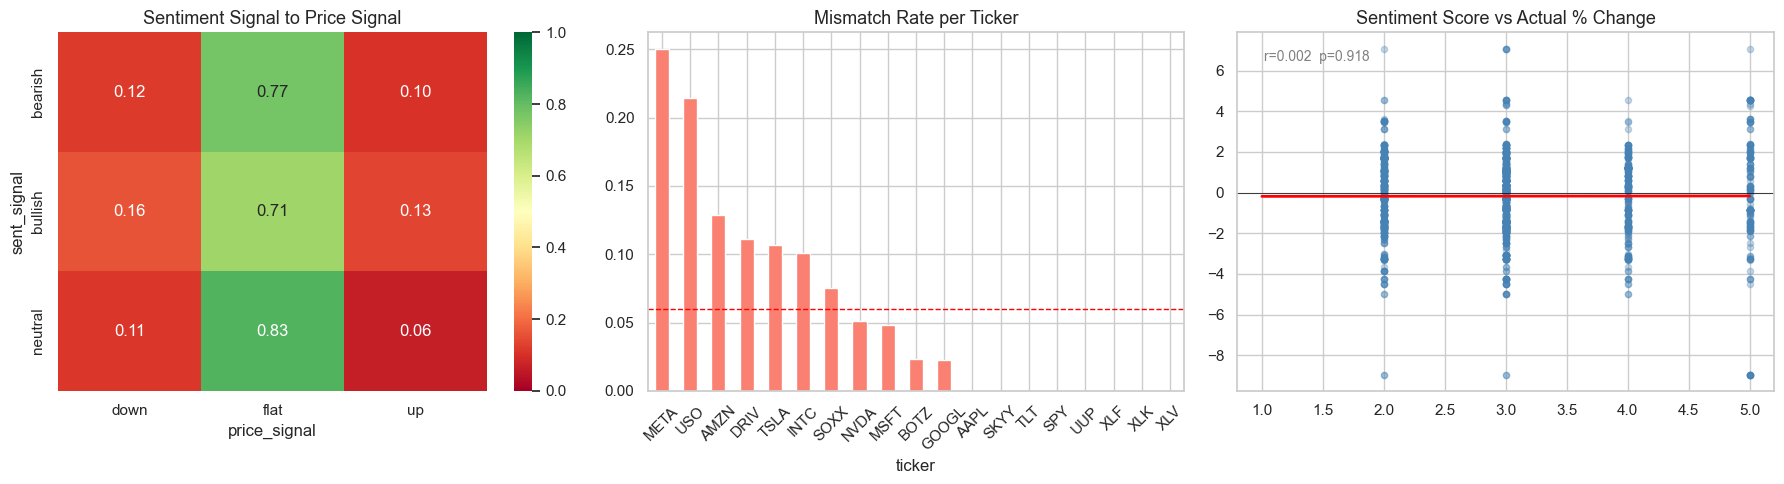


--- Confusion Matrix (counts) ---


price_signal,down,flat,up,Total
sent_signal,,,,
bearish,59,378,51,488
bullish,70,315,60,445
neutral,92,684,53,829
Total,221,1377,164,1762


  Saved: analysis\mismatch_confusion_matrix.csv

--- Mismatch Rate per Ticker ---


,mismatch_rate,mismatch_pct,flag
ticker,,,
META,0.250000,25.0,OK
USO,0.214286,21.4,OK
AMZN,0.128713,12.9,OK
DRIV,0.111111,11.1,OK
TSLA,0.107143,10.7,OK
INTC,0.101266,10.1,OK
SOXX,0.075000,7.5,OK
NVDA,0.050980,5.1,OK
MSFT,0.048077,4.8,OK


  Saved: analysis\mismatch_rate_per_ticker.csv

Overall mismatch rate: 6.9%
Pearson r: 0.002  p=0.9177  not significant yet


In [7]:
labeled = df.dropna(subset=['sentiment','bucket_1d']).copy()
labeled['sentiment']    = labeled['sentiment'].astype(int)
labeled['sent_signal']  = labeled['sentiment'].apply(
    lambda x: 'bullish' if x>=4 else ('bearish' if x<=2 else 'neutral'))
labeled['price_signal'] = labeled['bucket_1d'].apply(
    lambda x: 'up' if x in ('up','strong_up') else ('down' if x in ('down','strong_down') else 'flat'))
labeled['mismatch']     = (
    ((labeled['sent_signal']=='bullish') & (labeled['price_signal']=='down')) |
    ((labeled['sent_signal']=='bearish') & (labeled['price_signal']=='up'))
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = pd.crosstab(labeled['sent_signal'], labeled['price_signal'], normalize='index')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Sentiment Signal to Price Signal')
mismatch_rate = labeled.groupby('ticker')['mismatch'].mean().sort_values(ascending=False)
mismatch_rate.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].axhline(mismatch_rate.mean(), color='red', linestyle='--', linewidth=1)
axes[1].set_title('Mismatch Rate per Ticker')
axes[1].tick_params(axis='x', rotation=45)
sample = labeled.dropna(subset=['change_1d'])
axes[2].scatter(sample['sentiment'], sample['change_1d'], alpha=0.3, s=20, color='steelblue')
z = np.polyfit(sample['sentiment'], sample['change_1d'], 1)
xs = np.linspace(1, 5, 100)
axes[2].plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
axes[2].axhline(0, color='black', linewidth=0.5)
r, p_val = stats.pearsonr(sample['sentiment'], sample['change_1d'])
axes[2].annotate(f'r={r:.3f}  p={p_val:.3f}', xy=(0.05,0.92),
                 xycoords='axes fraction', fontsize=10,
                 color='red' if p_val<0.05 else 'grey')
axes[2].set_title('Sentiment Score vs Actual % Change')
plt.tight_layout(); plt.show()

# Tables
cm_counts = pd.crosstab(labeled['sent_signal'], labeled['price_signal'],
                        margins=True, margins_name='Total')
print('\n--- Confusion Matrix (counts) ---')
display(cm_counts)
save_csv(cm_counts, 'mismatch_confusion_matrix.csv')

mismatch_table = mismatch_rate.rename('mismatch_rate').to_frame()
mismatch_table['mismatch_pct'] = (mismatch_table['mismatch_rate']*100).round(1)
mismatch_table['flag'] = mismatch_table['mismatch_rate'].apply(
    lambda x: 'HIGH' if x>0.4 else 'OK')
print('\n--- Mismatch Rate per Ticker ---')
display(mismatch_table)
save_csv(mismatch_table, 'mismatch_rate_per_ticker.csv')

print(f'\nOverall mismatch rate: {labeled["mismatch"].mean()*100:.1f}%')
print(f'Pearson r: {r:.3f}  p={p_val:.4f}  {"significant" if p_val<0.05 else "not significant yet"}')

## 5 — Edge Cases

In [8]:
mismatches  = labeled[labeled['mismatch']].copy()
edge_cols   = ['date','ticker','sentiment','sent_signal','bucket_1d',
                'price_signal','change_1d','magnitude','summary','url']
edge_table  = mismatches[edge_cols].copy()
edge_table['date'] = edge_table['date'].dt.strftime('%Y-%m-%d')

print(f'Total mismatches: {len(edge_table)}')
print('\n--- Bullish Sentiment but Price Dropped (worst 10) ---')
display(edge_table[edge_table['sent_signal']=='bullish'].sort_values('change_1d').head(10))
print('\n--- Bearish Sentiment but Price Rose (top 10) ---')
display(edge_table[edge_table['sent_signal']=='bearish'].sort_values('change_1d', ascending=False).head(10))
save_csv(edge_table.set_index('url'), 'edge_cases.csv')

Total mismatches: 121

--- Bullish Sentiment but Price Dropped (worst 10) ---


,date,ticker,sentiment,sent_signal,bucket_1d,price_signal,change_1d,magnitude,summary,url
707,2026-03-20,USO,5,bullish,strong_down,down,-8.9517,large,"Oil prices surge to $113.71 per barrel, signif...",https://fortune.com/article/price-of-oil-03-19...
668,2026-03-20,USO,5,bullish,strong_down,down,-8.9517,large,Crude oil prices surge due to attacks on energ...,https://www.livemint.com/economy/crude-oil-pri...
665,2026-03-20,USO,5,bullish,strong_down,down,-8.9517,large,Crude oil prices surge due to escalating tensi...,https://www.livemint.com/market/commodities/oi...
574,2026-03-20,USO,5,bullish,strong_down,down,-8.9517,large,Indonesia's free meals programme and rising gl...,https://www.straitstimes.com/asia/se-asia/to-f...
941,2026-03-21,USO,5,bullish,strong_down,down,-8.9517,large,The Trump administration's waiver of sanctions...,https://www.straitstimes.com/world/middle-east...
931,2026-03-21,USO,5,bullish,strong_down,down,-8.9517,large,The rupee's depreciation due to rising crude o...,https://www.livemint.com/market/another-day-an...
912,2026-03-21,USO,5,bullish,strong_down,down,-8.9517,large,President Trump's criticism of NATO allies ove...,https://www.channelnewsasia.com/world/trump-na...
813,2026-03-21,USO,5,bullish,strong_down,down,-8.9517,large,United States Oil Fund shares surge as crude o...,https://www.benzinga.com/trading-ideas/movers/...
423,2026-03-19,INTC,4,bullish,strong_down,down,-5.0022,large,"Crimson Desert, a game using a proprietary eng...",https://www.tomshardware.com/pc-components/cpu...
422,2026-03-19,INTC,4,bullish,strong_down,down,-5.0022,large,AMD refreshes its Zen 5 chips to compete with ...,https://www.tomshardware.com/pc-components/cpu...



--- Bearish Sentiment but Price Rose (top 10) ---


,date,ticker,sentiment,sent_signal,bucket_1d,price_signal,change_1d,magnitude,summary,url
1279,2026-03-24,INTC,2,bearish,strong_up,up,7.0813,large,Gemini AI agents are monitoring the dark web f...,https://www.theregister.com/2026/03/23/google_...
1941,2026-03-28,USO,2,bearish,up,up,4.5330,moderate,Mortgage rates and oil prices are both surging...,https://www.benzinga.com/real-estate/26/03/515...
2015,2026-03-28,USO,2,bearish,up,up,4.5330,moderate,Goldman Sachs downgrades Indian equities due t...,https://www.livemint.com/market/stock-market-n...
1141,2026-03-23,USO,2,bearish,up,up,3.5999,moderate,"The Philippines' temporary use of cheaper, dir...",https://www.scmp.com/news/asia/southeast-asia/...
866,2026-03-21,TSLA,2,bearish,up,up,3.5031,moderate,Tesla's financial struggles and declining stoc...,https://www.benzinga.com/markets/prediction-ma...
930,2026-03-21,TSLA,2,bearish,up,up,3.5031,moderate,Elon Musk was found liable for misleading inve...,https://www.livemint.com/companies/jury-finds-...
910,2026-03-21,TSLA,2,bearish,up,up,3.5031,moderate,Elon Musk was found liable for allegedly defra...,https://www.channelnewsasia.com/business/elon-...
862,2026-03-21,TSLA,2,bearish,up,up,3.5031,moderate,Long-duration stocks suffered due to rising U....,https://www.benzinga.com/markets/equities/26/0...
900,2026-03-21,TSLA,2,bearish,up,up,3.5031,moderate,Tesla's financial struggles and declining stoc...,https://www.benzinga.com/markets/prediction-ma...
883,2026-03-21,TSLA,2,bearish,up,up,3.5031,moderate,The article details a legal case where Musk wa...,https://fortune.com/2026/03/20/musk-twitter-bu...


  Saved: analysis\edge_cases.csv


## 6 — Stock vs Benchmark Correlation

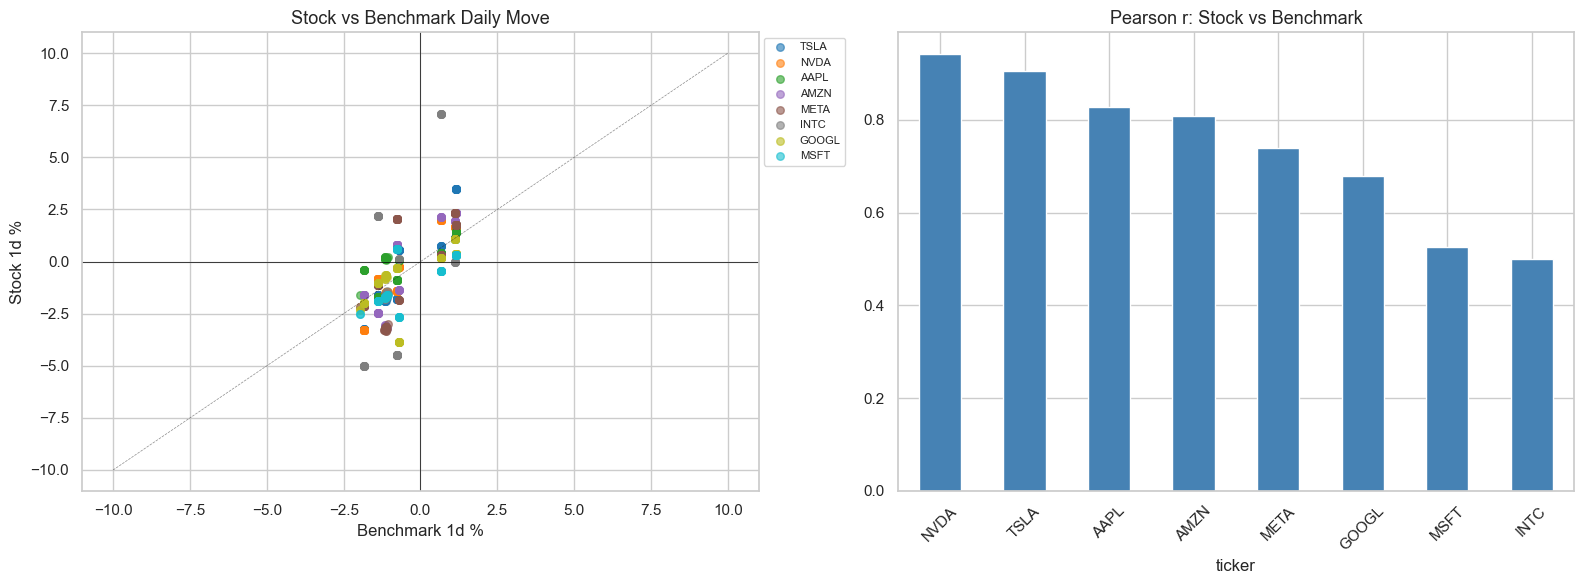


--- Stock vs Benchmark Correlation ---


,benchmark,r,p,n
ticker,,,,
NVDA,QQQ,0.942,0.0,255
TSLA,QQQ,0.906,0.0,84
AAPL,QQQ,0.828,0.0,133
AMZN,QQQ,0.809,0.0,101
META,QQQ,0.740,0.0,160
GOOGL,QQQ,0.679,0.0,131
MSFT,QQQ,0.526,0.0,104
INTC,QQQ,0.500,0.0,79


  Saved: analysis\correlations_stock_vs_benchmark.csv


In [9]:
company_df = df[df['category']=='company'].dropna(subset=['change_1d','bm_change_1d']).copy()
if company_df.empty:
    print('No data yet')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    tickers = company_df['ticker'].unique()
    colors  = plt.cm.tab10(np.linspace(0, 1, len(tickers)))
    for ticker, color in zip(tickers, colors):
        sub = company_df[company_df['ticker']==ticker]
        axes[0].scatter(sub['bm_change_1d'], sub['change_1d'],
                        label=ticker, alpha=0.6, s=30, color=color)
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].axvline(0, color='black', linewidth=0.5)
    axes[0].plot([-10,10],[-10,10],'k--',linewidth=0.5,alpha=0.5)
    axes[0].set_xlabel('Benchmark 1d %'); axes[0].set_ylabel('Stock 1d %')
    axes[0].set_title('Stock vs Benchmark Daily Move')
    axes[0].legend(bbox_to_anchor=(1,1), fontsize=8)
    corrs = []
    for ticker in tickers:
        sub = company_df[company_df['ticker']==ticker]
        if len(sub) > 5:
            r, p = stats.pearsonr(sub['bm_change_1d'], sub['change_1d'])
            corrs.append({'ticker': ticker, 'benchmark': sub['benchmark'].iloc[0],
                          'r': round(r,3), 'p': round(p,4), 'n': len(sub)})
    corr_df = pd.DataFrame(corrs).set_index('ticker').sort_values('r', ascending=False)
    corr_df['r'].plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Pearson r: Stock vs Benchmark')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
    print('\n--- Stock vs Benchmark Correlation ---')
    display(corr_df)
    save_csv(corr_df, 'correlations_stock_vs_benchmark.csv')

## 7 — Macro Impact on Stocks

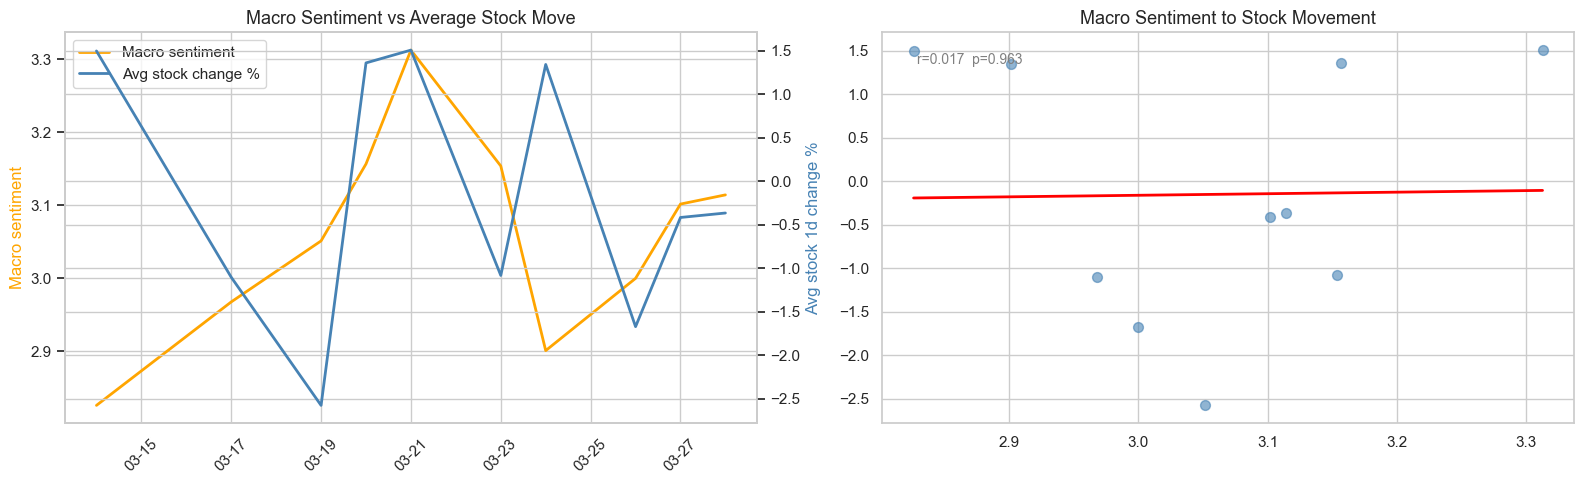


--- Daily Macro Sentiment vs Avg Stock Change ---


,date,macro_sentiment,avg_stock_change,macro_signal
0,2026-03-14,2.8261,1.4972,neutral
1,2026-03-17,2.9677,-1.1035,neutral
2,2026-03-19,3.0513,-2.5765,neutral
3,2026-03-20,3.1566,1.3598,neutral
4,2026-03-21,3.3125,1.5071,neutral
5,2026-03-23,3.1538,-1.0828,neutral
6,2026-03-24,2.9011,1.3419,neutral
7,2026-03-26,3.0000,-1.6718,neutral
8,2026-03-27,3.1017,-0.4166,neutral
9,2026-03-28,3.1143,-0.3654,neutral


  Saved: analysis\macro_vs_stocks.csv


In [10]:
macro_df    = df[df['category']=='sector/macro'].dropna(subset=['sentiment','date']).copy()
company_df2 = df[df['category']=='company'].dropna(subset=['change_1d','date']).copy()
if macro_df.empty or company_df2.empty:
    print('Not enough data yet')
else:
    daily_macro  = macro_df.groupby('date')['sentiment'].mean().reset_index()
    daily_macro.columns  = ['date','macro_sentiment']
    daily_stocks = company_df2.groupby('date')['change_1d'].mean().reset_index()
    daily_stocks.columns = ['date','avg_stock_change']
    merged = daily_macro.merge(daily_stocks, on='date')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax2 = axes[0].twinx()
    axes[0].plot(merged['date'], merged['macro_sentiment'], color='orange', linewidth=2, label='Macro sentiment')
    ax2.plot(merged['date'], merged['avg_stock_change'], color='steelblue', linewidth=2, label='Avg stock change %')
    axes[0].set_ylabel('Macro sentiment', color='orange')
    ax2.set_ylabel('Avg stock 1d change %', color='steelblue')
    axes[0].set_title('Macro Sentiment vs Average Stock Move')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    l1,lab1 = axes[0].get_legend_handles_labels()
    l2,lab2 = ax2.get_legend_handles_labels()
    axes[0].legend(l1+l2, lab1+lab2, loc='upper left')
    axes[1].scatter(merged['macro_sentiment'], merged['avg_stock_change'], alpha=0.6, s=50, color='steelblue')
    if len(merged) > 3:
        z = np.polyfit(merged['macro_sentiment'], merged['avg_stock_change'], 1)
        xs = np.linspace(merged['macro_sentiment'].min(), merged['macro_sentiment'].max(), 100)
        axes[1].plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
        r, p_val = stats.pearsonr(merged['macro_sentiment'], merged['avg_stock_change'])
        axes[1].annotate(f'r={r:.3f}  p={p_val:.3f}', xy=(0.05,0.92),
                         xycoords='axes fraction', fontsize=10,
                         color='red' if p_val<0.05 else 'grey')
    axes[1].set_title('Macro Sentiment to Stock Movement')
    plt.tight_layout(); plt.show()

    macro_table = merged.copy()
    macro_table['date'] = macro_table['date'].dt.strftime('%Y-%m-%d')
    macro_table = macro_table.round(4)
    macro_table['macro_signal'] = macro_table['macro_sentiment'].apply(
        lambda x: 'bullish' if x>=4 else ('bearish' if x<=2 else 'neutral'))
    print('\n--- Daily Macro Sentiment vs Avg Stock Change ---')
    display(macro_table)
    save_csv(macro_table.set_index('date'), 'macro_vs_stocks.csv')

## 8 — Sector Sentiment vs Constituent Stock Performance

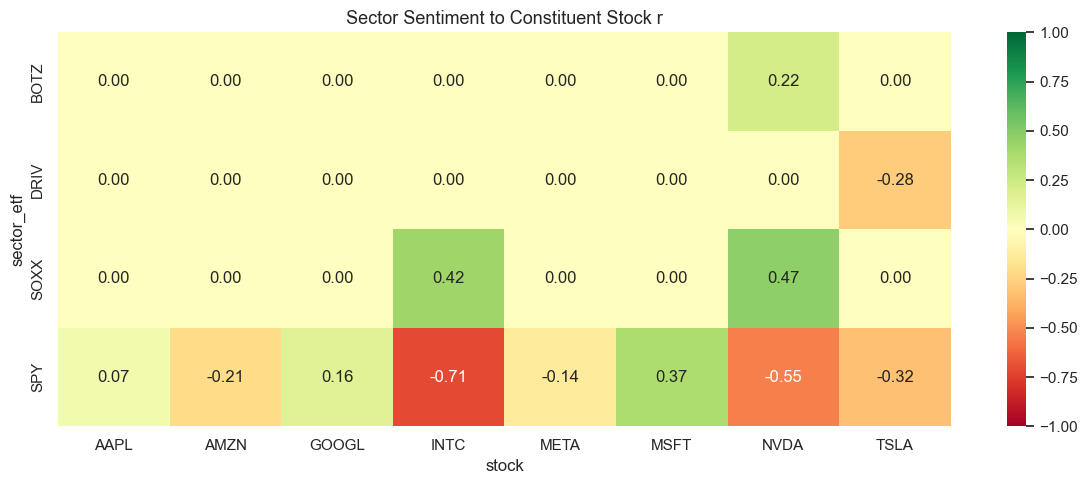


--- Sector Sentiment to Stock Correlation ---


,sector_etf,sector_name,stock,r,p,n_days,significant
0,SOXX,Semiconductor,NVDA,0.474,0.1667,10,No
1,SOXX,Semiconductor,INTC,0.420,0.2274,10,No
6,SPY,S&P500,MSFT,0.370,0.3663,8,No
2,BOTZ,AI/Robotics,NVDA,0.216,0.5480,10,No
10,SPY,S&P500,GOOGL,0.159,0.6837,9,No
5,SPY,S&P500,AAPL,0.069,0.8603,9,No
7,SPY,S&P500,META,-0.139,0.7219,9,No
9,SPY,S&P500,AMZN,-0.213,0.5826,9,No
3,DRIV,EV,TSLA,-0.280,0.4335,10,No
8,SPY,S&P500,TSLA,-0.322,0.3978,9,No


  Saved: analysis\correlations_sector_vs_stocks.csv


In [11]:
SECTOR_STOCKS = {
    'QQQ':  ['NVDA','AAPL','MSFT','META','TSLA','AMZN','GOOGL','INTC','AMD'],
    'SOXX': ['NVDA','INTC','AMD'],
    'BOTZ': ['NVDA'],
    'DRIV': ['TSLA'],
    'SPY':  ['NVDA','AAPL','MSFT','META','TSLA','AMZN','GOOGL','INTC','AMD'],
}
sector_df   = df[df['category']=='sector/macro'].dropna(subset=['sentiment','date']).copy()
company_df3 = df[df['category']=='company'].dropna(subset=['change_1d','date']).copy()
results = []
for sector_ticker, stock_tickers in SECTOR_STOCKS.items():
    sector_news = sector_df[sector_df['ticker']==sector_ticker]
    if sector_news.empty: continue
    daily_sector = sector_news.groupby('date')['sentiment'].mean()
    for stock in stock_tickers:
        stock_prices = company_df3[company_df3['ticker']==stock]
        if stock_prices.empty: continue
        daily_stock = stock_prices.groupby('date')['change_1d'].mean()
        merged = daily_sector.rename('sector_sent').reset_index() \
            .merge(daily_stock.rename('stock_chg').reset_index(), on='date')
        if len(merged) < 5: continue
        r, p_val = stats.pearsonr(merged['sector_sent'], merged['stock_chg'])
        results.append({'sector_etf': sector_ticker,
                        'sector_name': ETF_LABELS.get(sector_ticker, sector_ticker),
                        'stock': stock, 'r': round(r,3), 'p': round(p_val,4),
                        'n_days': len(merged),
                        'significant': 'Yes' if p_val<0.05 else 'No'})
if results:
    res_df  = pd.DataFrame(results)
    pivot_r = res_df.pivot_table(index='sector_etf', columns='stock', values='r', fill_value=0)
    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot_r, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1)
    plt.title('Sector Sentiment to Constituent Stock r')
    plt.tight_layout(); plt.show()
    print('\n--- Sector Sentiment to Stock Correlation ---')
    display(res_df.sort_values('r', ascending=False))
    save_csv(res_df.set_index(['sector_etf','stock']), 'correlations_sector_vs_stocks.csv')
else:
    print('Not enough overlapping dates yet')

## 9 — Dataset Readiness Summary

In [12]:
labeled = df.dropna(subset=['sentiment','bucket_1d'])

ticker_ready = labeled.groupby(['ticker','category']).agg(
    total_articles  = ('url',       'count'),
    unique_days     = ('date',      'nunique'),
    avg_sentiment   = ('sentiment', 'mean'),
    flat_pct        = ('bucket_1d', lambda x: round((x=='flat').mean()*100,1)),
    strong_down_pct = ('bucket_1d', lambda x: round((x=='strong_down').mean()*100,1)),
    strong_up_pct   = ('bucket_1d', lambda x: round((x=='strong_up').mean()*100,1)),
).round(2).reset_index()
ticker_ready['imbalance_flag'] = ticker_ready['flat_pct'].apply(
    lambda x: 'HIGH FLAT' if x>70 else 'OK')
ticker_ready['readiness'] = ticker_ready['total_articles'].apply(
    lambda x: 'LOW <50' if x<50 else ('MED 50-200' if x<200 else 'READY 200+'))

print('='*60)
print('DATASET READINESS SUMMARY')
print('='*60)
print(f'Total articles:    {len(df):>6,}')
print(f'With sentiment:    {df["sentiment"].notna().sum():>6,}')
print(f'With price bucket: {df["bucket_1d"].notna().sum():>6,}')
print(f'Fully labeled:     {len(labeled):>6,}')
print()
display(ticker_ready)
save_csv(ticker_ready.set_index('ticker'), 'dataset_readiness.csv')

total = len(labeled)
print()
if total < 500:
    print(f'  {total} examples — keep collecting (target 500+)')
elif total < 2000:
    print(f'  {total} examples — borderline, proceed with caution')
else:
    print(f'  {total} examples — ready to fine-tune!')

print(f'\nCSVs in {ANALYSIS_DIR}/')
for f in sorted(os.listdir(ANALYSIS_DIR)):
    if f.endswith('.csv'):
        print(f'  {f}')

DATASET READINESS SUMMARY
Total articles:     2,414
With sentiment:     1,992
With price bucket:  1,762
Fully labeled:      1,762



,ticker,category,total_articles,unique_days,avg_sentiment,flat_pct,strong_down_pct,strong_up_pct,imbalance_flag,readiness
0,AAPL,company,133,10,3.27,100.0,0.0,0.0,HIGH FLAT,MED 50-200
1,AMZN,company,101,10,3.38,55.4,0.0,0.0,OK,MED 50-200
2,BOTZ,sector/macro,43,10,2.79,90.7,0.0,0.0,HIGH FLAT,LOW <50
3,DRIV,sector/macro,45,10,3.13,75.6,0.0,0.0,HIGH FLAT,LOW <50
4,GOOGL,company,131,10,2.83,90.1,0.0,0.0,HIGH FLAT,MED 50-200
5,INTC,company,79,10,3.03,51.9,11.4,7.6,OK,MED 50-200
6,META,company,160,10,2.91,44.4,0.0,0.0,OK,MED 50-200
7,MSFT,company,104,8,3.14,91.3,0.0,0.0,HIGH FLAT,MED 50-200
8,NVDA,company,255,10,3.14,87.5,0.0,0.0,HIGH FLAT,READY 200+
9,SKYY,sector/macro,58,10,2.90,51.7,0.0,0.0,OK,MED 50-200


  Saved: analysis\dataset_readiness.csv

  1762 examples — borderline, proceed with caution

CSVs in analysis/
  correlations_sector_vs_stocks.csv
  correlations_stock_vs_benchmark.csv
  dataset_readiness.csv
  dist_articles_per_day.csv
  dist_articles_per_ticker.csv
  dist_magnitude.csv
  dist_price_buckets.csv
  dist_price_buckets_per_ticker.csv
  dist_sentiment.csv
  dist_sentiment_per_ticker.csv
  dist_ticker_day_heatmap.csv
  edge_cases.csv
  macro_vs_stocks.csv
  mismatch_confusion_matrix.csv
  mismatch_rate_per_ticker.csv
